# Error Analysis Notebook

Analyze Visual Odometry (VO), Wheel Odometry (WO), and Extended Kalman Filter (EKF) errors across different datasets.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Load available CSV files
data_dir = Path("../data")
csv_files = list(data_dir.glob("*_errors.csv"))

print(f"Found {len(csv_files)} CSV files:")
for i, file in enumerate(csv_files):
    print(f"  {i+1}. {file.name}")

Found 2 CSV files:
  1. ComplexUrbanDatasetLoader_errors.csv
  2. robot_xfeat_bruteforce_errors.csv


In [27]:
# Load and display second dataset
df1 = pd.read_csv("../data/robot_xfeat_bruteforce_errors.csv")
print("robot_xfeat_bruteforce_errors.csv")
print(f"Shape: {df1.shape}")
print("\nFirst 10 rows:")
print(df1.head(10))
print("\nBasic Statistics:")
print(df1.describe())

robot_xfeat_bruteforce_errors.csv
Shape: (16, 4)

First 10 rows:
   Frame      VO_Error      WO_Error     EKF_Error
0      0  1.110223e-16  1.110223e-16  1.110223e-16
1      1  1.539069e-02  9.956679e-03  1.421094e-02
2      2  1.662377e-02  1.078627e-02  1.333946e-02
3      3  2.469818e-02  8.201904e-03  1.806558e-02
4      4  3.538126e-02  1.345852e-02  2.558135e-02
5      5  4.595754e-02  1.814377e-02  3.204257e-02
6      6  5.754639e-02  2.296110e-02  3.972252e-02
7      7  7.163016e-02  2.987315e-02  4.935819e-02
8      8  8.172376e-02  3.529967e-02  5.368532e-02
9      9  7.497258e-02  3.953644e-02  4.738801e-02

Basic Statistics:
           Frame      VO_Error      WO_Error     EKF_Error
count  16.000000  1.600000e+01  1.600000e+01  1.600000e+01
mean    7.500000  6.404015e-02  3.413090e-02  4.280406e-02
std     4.760952  3.669130e-02  2.311209e-02  2.323312e-02
min     0.000000  1.110223e-16  1.110223e-16  1.110223e-16
25%     3.750000  3.271049e-02  1.279046e-02  2.370241e-02
5

## Visualization: Error Trajectories

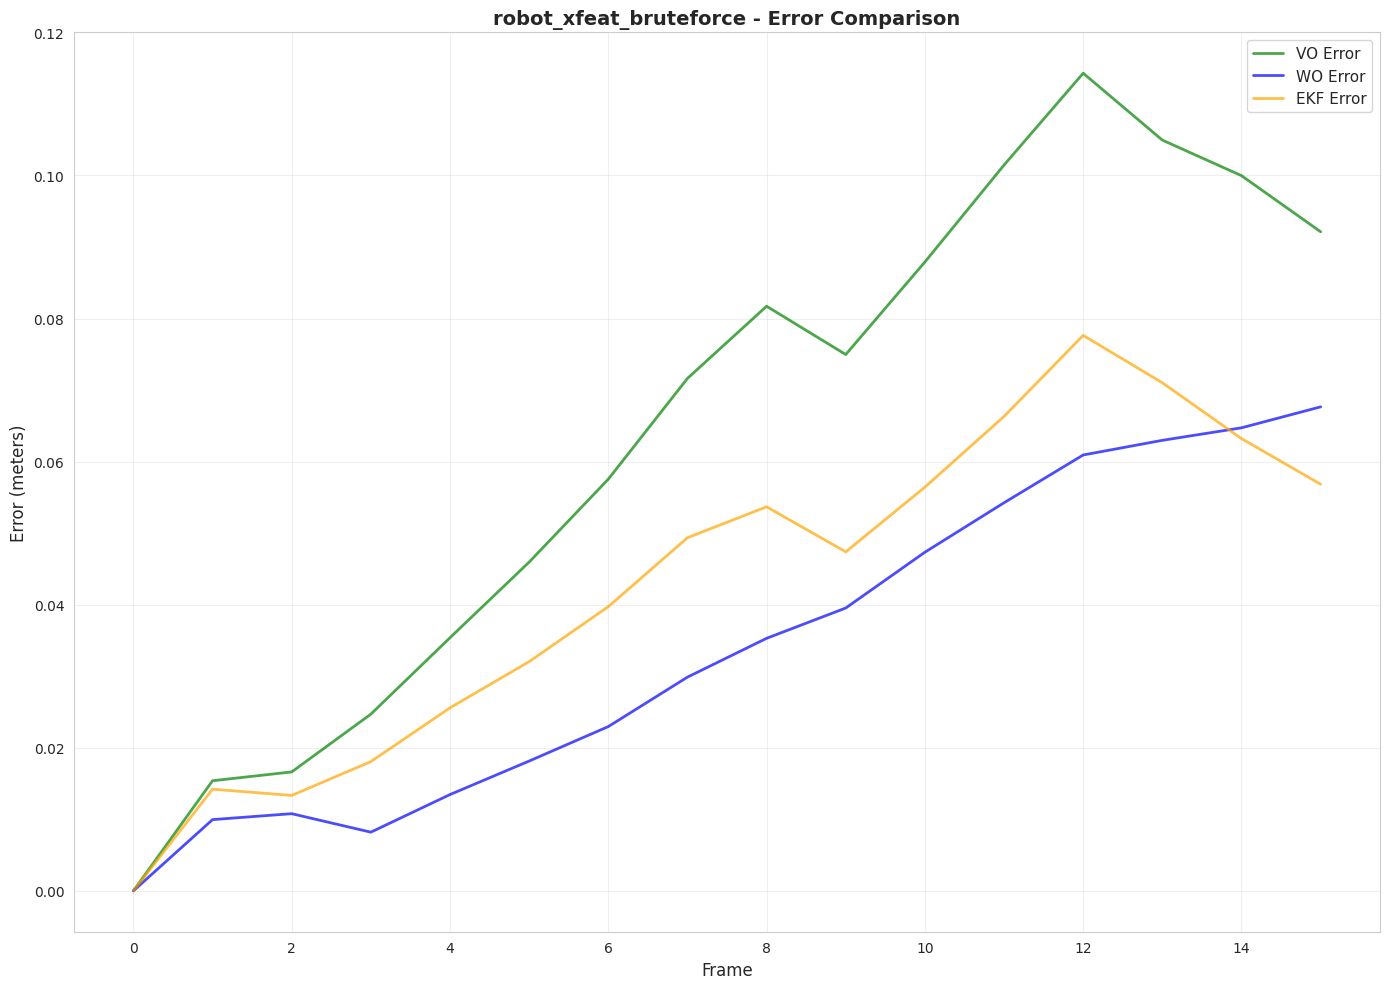

In [28]:
fig, axes = plt.subplots(figsize=(14, 10))


# Dataset 2 - robot_xfeat_bruteforce
axes.plot(df1['Frame'], df1['VO_Error'], label='VO Error', linewidth=2, color='green', alpha=0.7)
axes.plot(df1['Frame'], df1['WO_Error'], label='WO Error', linewidth=2, color='blue', alpha=0.7)
axes.plot(df1['Frame'], df1['EKF_Error'], label='EKF Error', linewidth=2, color='orange', alpha=0.7)
axes.set_xlabel('Frame', fontsize=12)
axes.set_ylabel('Error (meters)', fontsize=12)
axes.set_title('robot_xfeat_bruteforce - Error Comparison', fontsize=14, fontweight='bold')
axes.legend(fontsize=11)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Statistical Comparison

In [29]:
# Create summary statistics table
stats_data = {
    'Dataset': ['Robot_Xfeat', 'Robot_Xfeat', 'Robot_Xfeat'],
    'Method': ['VO', 'WO', 'EKF'],
    'Mean Error': [df1['VO_Error'].mean(), df1['WO_Error'].mean(), df1['EKF_Error'].mean()],
    'Std Dev': [df1['VO_Error'].std(), df1['WO_Error'].std(), df1['EKF_Error'].std()],
    'Min Error': [df1['VO_Error'].min(), df1['WO_Error'].min(), df1['EKF_Error'].min()],
    'Max Error': [df1['VO_Error'].max(), df1['WO_Error'].max(), df1['EKF_Error'].max()]
}

stats_df = pd.DataFrame(stats_data)
print("Error Statistics Comparison:")
print(stats_df.to_string(index=False))

Error Statistics Comparison:
    Dataset Method  Mean Error  Std Dev    Min Error  Max Error
Robot_Xfeat     VO    0.064040 0.036691 1.110223e-16   0.114296
Robot_Xfeat     WO    0.034131 0.023112 1.110223e-16   0.067657
Robot_Xfeat    EKF    0.042804 0.023233 1.110223e-16   0.077646


## Box Plot Comparison

/tmp/ipykernel_13301/989114056.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1_melted, x='Method', y='Error', ax=axes, palette='Set2')


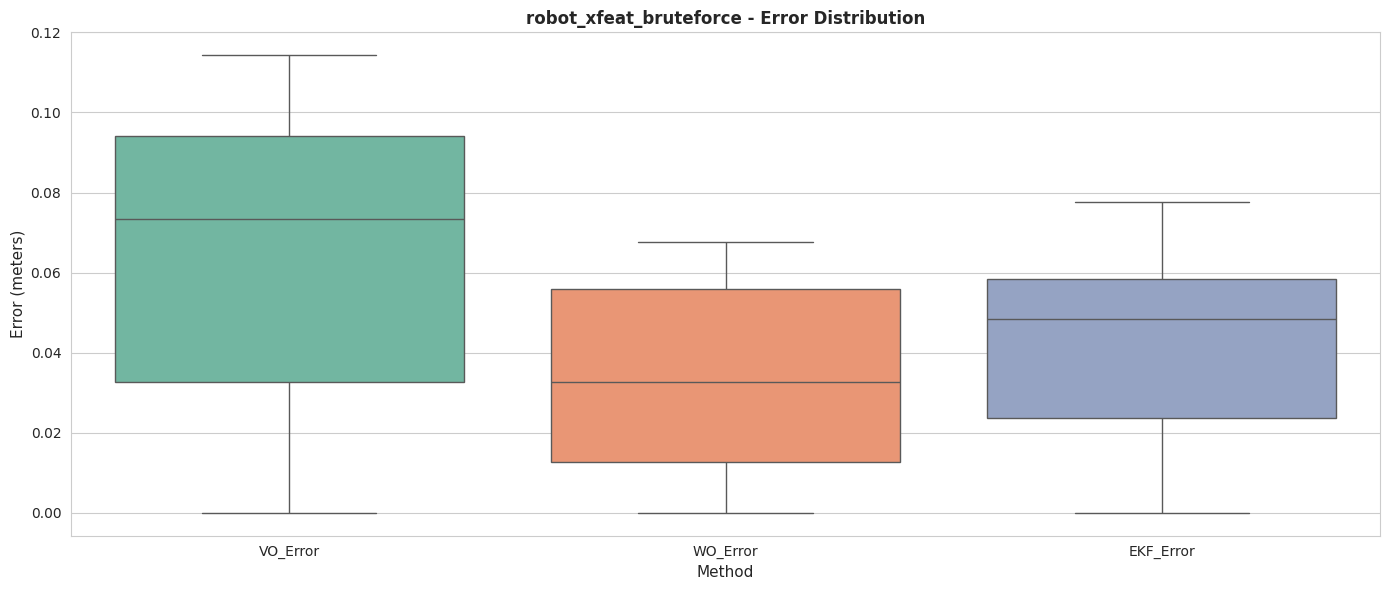

In [30]:
fig, axes = plt.subplots(figsize=(14, 6))

# Dataset 1 box plot
df1_melted = df1[['VO_Error', 'WO_Error', 'EKF_Error']].melt(var_name='Method', value_name='Error')
sns.boxplot(data=df1_melted, x='Method', y='Error', ax=axes, palette='Set2')
axes.set_title('robot_xfeat_bruteforce - Error Distribution', fontsize=12, fontweight='bold')
axes.set_ylabel('Error (meters)', fontsize=11)
axes.set_xlabel('Method', fontsize=11)

plt.tight_layout()
plt.show()

## Performance Summary

In [31]:
# Performance metrics
print("=" * 70)
print("PERFORMANCE SUMMARY")
print("=" * 70)

print("\n🤖 robot_xfeat_bruteforce Dataset:")
print(f"  Total Frames: {len(df1)}")
print(f"  VO - Mean Error: {df1['VO_Error'].mean():.6f}m (±{df1['VO_Error'].std():.6f}m)")
print(f"  WO - Mean Error: {df1['WO_Error'].mean():.6f}m (±{df1['WO_Error'].std():.6f}m)")
print(f"  EKF - Mean Error: {df1['EKF_Error'].mean():.6f}m (±{df1['EKF_Error'].std():.6f}m)")
print(f"  Best Method: {['VO', 'WO', 'EKF'][np.argmin([df1['VO_Error'].mean(), df1['WO_Error'].mean(), df1['EKF_Error'].mean()])]}")


print("\n✅ Analysis Complete!")
print("=" * 70)

PERFORMANCE SUMMARY

🤖 robot_xfeat_bruteforce Dataset:
  Total Frames: 16
  VO - Mean Error: 0.064040m (±0.036691m)
  WO - Mean Error: 0.034131m (±0.023112m)
  EKF - Mean Error: 0.042804m (±0.023233m)
  Best Method: WO

✅ Analysis Complete!
